# Characterizing Aberrations with Optuna

<a href="https://colab.research.google.com/github/softmatterlab/DeepTrack-2.0/blob/develop/examples/tutorials/1-getting-started/DTSG127_characterizing_aberrations_optuna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !pip install deeptrack  # Uncomment if running on Colab/Kaggle.

In [2]:
# !pip install optuna  # Uncomment if needed.

This tutorial demonstrates how to identify the type and coefficient of an optical aberration using the image of a centered particle. You first simulate a reference image of the particle imaged through a microscope with a randomly chosen aberration, then use Optuna to search over aberration type, coefficient, and particle radius to find the simulated image that best matches the reference image, and finally compare the best-fit aberration against the reference image.

In [3]:
import random

import deeptrack as dt
import numpy as np
from matplotlib import pyplot as plt
import optuna

## 1. Defining the Aberrations

Here you gather all aberration types that DeepTrack2 can simulate into a list. 

Aberrations in DeepTrack2 are wrappers of the more general `Zernike` feature, which introduces a phase to the pupil function based on the normalized Zernike polynomials. The property `coefficient` is a multiplier for the respective polynomial in the set of Zernike polynomials.

See more details in [DTATo40_aberrations](../3-advanced-topics/DTATo40_aberrations.ipynb).

In [4]:
aberration_types = [
    dt.Piston,
    dt.VerticalTilt,
    dt.HorizontalTilt,
    dt.ObliqueAstigmatism,
    dt.Defocus,
    dt.Astigmatism,
    dt.ObliqueTrefoil,
    dt.VerticalComa,
    dt.HorizontalComa,
    dt.Trefoil,
    dt.SphericalAberration,
]

## 2. Defining the Features

Define the features needed for this example:

* `optics`: Fluorescence microscope with a pixel size of 0.1 microns and a 256×256-pixel output region.

* `particle`: Spherical particle centered in the image with 1e-6 meter radius.


In [5]:
IMAGE_SIZE = 256

# Define optics.
optics = dt.Fluorescence(
    magnification=15,
    resolution=1e-6,
    wavelength=660e-9,
    output_region=(0, 0, IMAGE_SIZE, IMAGE_SIZE),
)

# Define scatterer.
particle = dt.Sphere(
    position=(IMAGE_SIZE // 2, IMAGE_SIZE // 2, 0),
    radius=1e-6,
    intensity=1,
)

## 3. Combining the Features

To image the particle through the aberrated microscope, choose a random aberration from the list and modify the pupil function of the `optics` microscope with `optics.pupil`.

In [6]:
# Pick a random aberration from the list.
aberration = random.choice(aberration_types)

# Pick a random aberration strength.
aberration = aberration(coefficient=lambda: (2 * np.random.rand() - 1) * 4)

# Modify the pupil of the microscope with the aberration.
optics.pupil = aberration

Image the particle through the randomly aberrated microscope to generate the reference image that the optimization below will try to match.

Aberration type: SphericalAberration
Coefficient: 3.7933678093448373
Radius: 1e-06



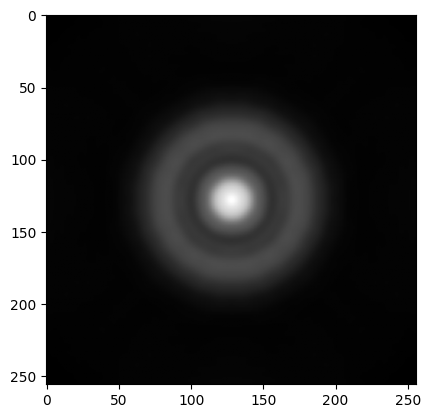

In [7]:
reference_image = optics(particle).resolve().squeeze()

plt.imshow(reference_image, cmap="gray")

print(
    f"Aberration type: {aberration.name()}\n"
    f"Coefficient: {aberration.coefficient()}\n"
    f"Radius: {particle.radius()}\n"
)

## 4. Preparing the Simulation Function for Optuna

Optuna is a hyperparameter optimization framework which lets you explore a large number of parameters with a variety of search methods.

In this tutorial, you will use the default [Tree-Structured Parzen Estimator](https://optuna.readthedocs.io/en/stable/reference/samplers/generated/optuna.samplers.TPESampler.html#optuna.samplers.TPESampler), restrict the search space to four parameters, and score each candidate image with a simple RMSE loss function, which measures the average pixel-wise intensity difference between the candidate image and the reference image generated above.

The search parameters are:

* Aberration category

* Aberration strength coefficient

* Particle radius in meters

In [8]:
def simulate_aberrated_image(
    aberration_candidate,       # Aberration category
    coefficient,                # Aberration coefficient
    radius,                     # Particle radius
):
    # Get the aberration type and modify the pupil.
    simulated_aberration = aberration_candidate(coefficient=coefficient)
    optics.pupil = simulated_aberration

    # Instance the particle with the trial parameters.
    particle = dt.Sphere(
        radius=radius,
        position=(IMAGE_SIZE // 2, IMAGE_SIZE // 2),
        intensity=1,
    )

    # Image the particle through the aberrated microscope.
    simulated_image = optics(particle).resolve().squeeze()

    return simulated_image.astype(np.float32)

## 5. Preparing the Workflow for Optuna

The following function defines the search parameters and loss function that will be used.

In [9]:
def objective(trial):
    """Optuna objective function for aberration and particle parameters."""

    # Vary aberration type using the list defined at the start.
    aberration_name = trial.suggest_categorical(
        "aberration_name", [cls.__name__ for cls in aberration_types]
    )
    aberration_type = next(
        cls for cls in aberration_types if cls.__name__ == aberration_name
    )

    # Vary aberration strength.
    coefficient = trial.suggest_float("coefficient", -4, 4)

    # Vary particle radius.
    radius = trial.suggest_float("radius", 0.8e-7, 1.2e-6)

    # Generate a simulated image with the parameters.
    simulated_image = simulate_aberrated_image(
        aberration_type,
        coefficient,
        radius,
    )

    # Pixel-wise RMSE comparison between the reference and the simulated image.
    loss = np.sqrt(
        np.mean(
            np.square(
                simulated_image - reference_image
                )
            )
        )

    return loss

## 6. Running the Optimization

You are now ready to run the Optuna study, which you will do for a number of trials set by `n_trials`. At each iteration the loss along with the parameters will be printed which allows you to track the progress.

In [10]:
# Run Optuna study.
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=500)

print("Best Loss:", study.best_value)
print("Best parameters:", study.best_trial.params)

[I 2026-09-16 14:26:47,734] A new study created in memory with name: no-name-13ce1b81-5dd8-441a-a4a4-1071875a932f
[I 2026-09-16 14:26:48,237] Trial 0 finished with value: 0.0026847283551748565 and parameters: {'aberration_name': 'SphericalAberration', 'coefficient': -2.326814399734574, 'radius': 8.616733692865972e-07}. Best is trial 0 with value: 0.0026847283551748565.
[I 2026-09-16 14:26:48,399] Trial 1 finished with value: 0.005070434781147406 and parameters: {'aberration_name': 'ObliqueTrefoil', 'coefficient': -2.6620104138891154, 'radius': 2.5089681469974915e-07}. Best is trial 0 with value: 0.0026847283551748565.
[I 2026-09-16 14:26:48,899] Trial 2 finished with value: 0.019947625244065074 and parameters: {'aberration_name': 'VerticalTilt', 'coefficient': 3.1756257418973295, 'radius': 8.861044437026565e-07}. Best is trial 0 with value: 0.0026847283551748565.
[I 2026-09-16 14:26:49,353] Trial 3 finished with value: 0.0040833873323868975 and parameters: {'aberration_name': 'Vertical

Best Loss: 1.850875194607996e-07
Best parameters: {'aberration_name': 'SphericalAberration', 'coefficient': -3.793437770529111, 'radius': 9.986271337978935e-07}


## 7.  Validating the Results

With the optimization completed, extract the parameters that minimized the loss function and reproduce the image.

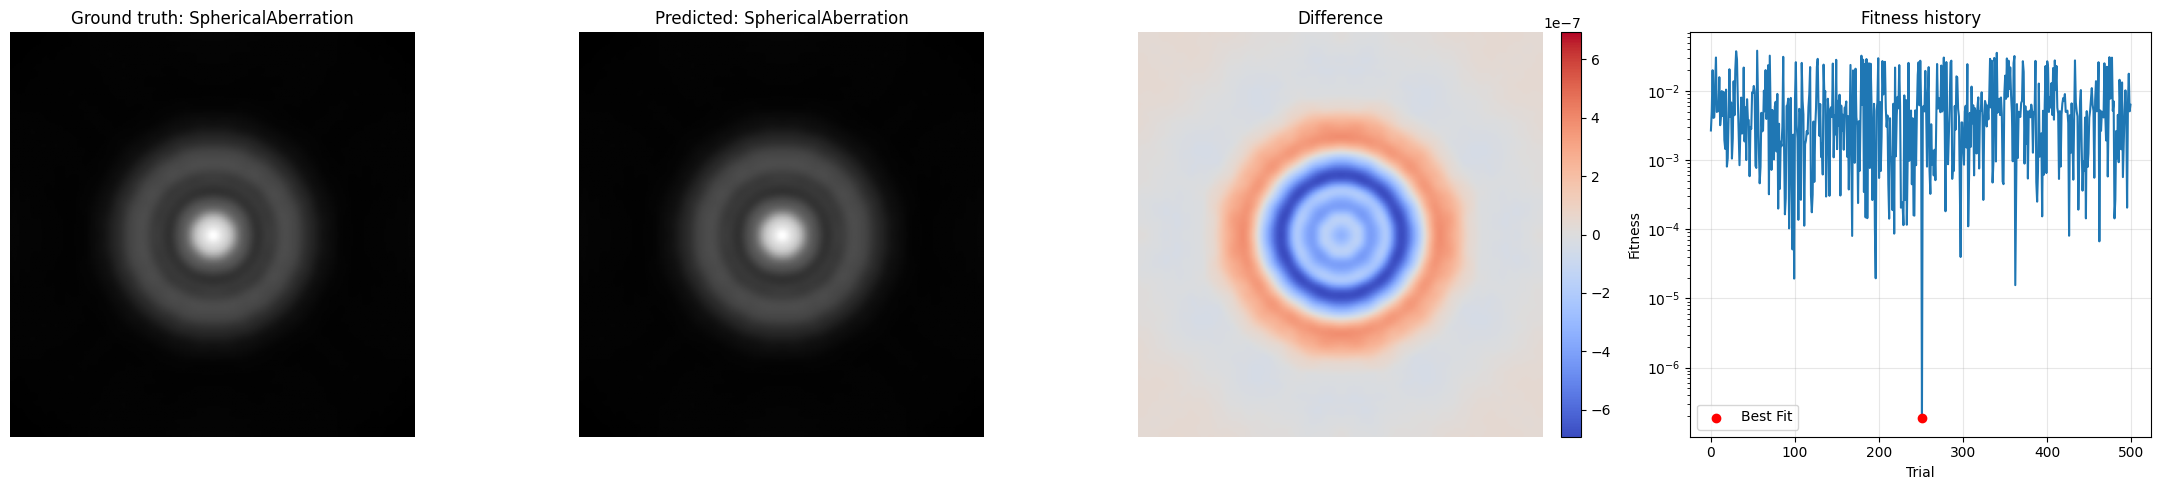

Parameter       Ground Truth         Predicted           
-------------------------------------------------------
Aberration      SphericalAberration  SphericalAberration
Coefficient     3.7933678093448373   -3.793437770529111
Radius          1e-06                9.986271337978935e-07


In [12]:
# Get best parameters from the study.
best_params = study.best_trial.params
coeff = best_params["coefficient"]

# Reconstruct the image which had the optimal parameters.
predicted_aberration = study.best_params["aberration_name"]

# Convert string back to class.
aberration_class = next(
    cls for cls in aberration_types if cls.__name__ == predicted_aberration
)

# Create aberration instance.
predicted_aberration = aberration_class(coefficient=coeff)

optics.pupil = predicted_aberration

predicted_particle = dt.Sphere(
    radius=best_params["radius"],
    position=(IMAGE_SIZE // 2, IMAGE_SIZE // 2),
    intensity=1,
)

# Generate predicted image.
predicted_image = optics(predicted_particle).resolve().squeeze()

# Calculate difference.
difference = predicted_image - reference_image

# Fitness history.
trials = [
    trial for trial in study.trials
    if trial.state == optuna.trial.TrialState.COMPLETE
]

fitness = [trial.value for trial in trials]
trial_numbers = [trial.number for trial in trials]

fig, ax = plt.subplots(1, 4, figsize=(22, 5))

ax[0].imshow(reference_image, cmap="gray")
ax[0].set_title(f"Ground truth: {aberration.name()}")
ax[0].axis("off")

ax[1].imshow(predicted_image, cmap="gray")
ax[1].set_title(f"Predicted: {predicted_aberration.name()}")
ax[1].axis("off")

max_diff = np.max(np.abs(difference))

im = ax[2].imshow(
    difference,
    cmap="coolwarm",
    vmin=-max_diff,
    vmax=max_diff,
)
ax[2].set_title("Difference")
ax[2].axis("off")
fig.colorbar(im, ax=ax[2], fraction=0.046, pad=0.04)

ax[3].semilogy(trial_numbers, fitness)
ax[3].scatter(
    study.best_trial.number,
    study.best_trial.value,
    zorder=3,
    c="red",
    label="Best Fit",
)
ax[3].legend()
ax[3].set_xlabel("Trial")
ax[3].set_ylabel("Fitness")
ax[3].set_title("Fitness history")
ax[3].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(
    f"{'Parameter':<15} {'Ground Truth':<20} {'Predicted':<20}\n"
    f"{'-' * 55}\n"
    f"{'Aberration':<15} {aberration.name():<20} {best_params['aberration_name']}\n"
    f"{'Coefficient':<15} {aberration.coefficient():<20} {best_params['coefficient']}\n"
    f"{'Radius':<15} {particle.radius():<20} {best_params['radius']}"
)